In [1]:
import pandas as pd
import numpy as np
from autogluon.tabular import TabularDataset, TabularPredictor
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
odroid1 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_7/odroid1_firefox_carbonyl7.csv")
odroid2 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_7/odroid2_firefox_carbonyl7.csv")
odroid3 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_7/odroid3_firefox_carbonyl7.csv")
odroid4 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_7/odroid4_firefox_carbonyl7.csv")

In [3]:
rpi4a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_7/rpi-4a_chrome_carbonyl7.csv")
rpi8a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_7/rpi-8a_chrome_carbonyl7.csv")
rpi8b = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_7/rpi_8b_carbonyl_onscreen.csv")
rpi8c = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_7/rpi_8c_carbonyl_onscreen.csv")
rpi8d = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_7/rpi-8d_chrome_carbonyl7.csv")

In [4]:
df = pd.concat([odroid1[:1000], odroid2[:1000], odroid3[:1000], odroid4[:1000], rpi4a[:1000], rpi8a[:1000], rpi8b[:1000], rpi8c[:1000], rpi8d[:1000]])
df = df.sample(frac=1).reset_index(drop=True)

In [5]:
df.head()

,label,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6
0,odroid4,87.1,85.8,84.7,83.5,82.7,83.3,83.5
1,rpi_8c,63.2,61.6,61.5,60.1,60.3,73.4,85.7
2,rpi_8b,62.9,61.6,60.8,60.1,60.7,61.6,60.9
3,odroid4,87.5,88.1,85.2,84.0,83.7,83.7,83.3
4,odroid1,88.3,86.1,85.6,84.0,83.6,83.7,84.5


In [6]:
len(df)

9000

In [7]:
stats_df = pd.DataFrame(columns=['data_amount', 'precision', 'recall', 'f1'])
best_model = {}
best_features = {}

for i in range(1000, 9000, 1000):
    train_data = df.head(i)
    test_data = df.tail(1000)

    predictor = TabularPredictor(label='label').fit(train_data, num_gpus=1, presets='medium_quality')
    y_pred = predictor.predict(test_data)
    y_pred_proba = predictor.predict_proba(test_data)
    results = predictor.evaluate(test_data, detailed_report=True)['classification_report']['weighted avg']

    new_row = {'data_amount': i, 'precision': results['precision'], 'recall':results['recall'], 'f1':results['f1-score']}
    stats_df.loc[len(stats_df)] = new_row

    model_leaderboard = predictor.leaderboard(test_data)
    # Which models came in the top three on the leaderboard most often?
    if model_leaderboard.loc[0]['model'] not in best_model:
        best_model[model_leaderboard.loc[0]['model']] = 1
    else:
        best_model[model_leaderboard.loc[0]['model']] += 1

    if model_leaderboard.loc[1]['model'] not in best_model:
        best_model[model_leaderboard.loc[1]['model']] = 1
    else:
        best_model[model_leaderboard.loc[1]['model']] += 1

    if model_leaderboard.loc[2]['model'] not in best_model:
        best_model[model_leaderboard.loc[2]['model']] = 1
    else:
        best_model[model_leaderboard.loc[2]['model']] += 1


    feature_importance = predictor.feature_importance(test_data)
    # Which features has the highest importance most often?
    if feature_importance.index[0] not in best_features:
        best_features[feature_importance.index[0]] = 1
    else:
        best_features[feature_importance.index[0]] += 1

    if feature_importance.index[1] not in best_features:
        best_features[feature_importance.index[1]] = 1
    else:
        best_features[feature_importance.index[1]] += 1

    if feature_importance.index[2] not in best_features:
        best_features[feature_importance.index[2]] = 1
    else:
        best_features[feature_importance.index[2]] += 1

No path specified. Models will be saved in: "AutogluonModels/ag-20240912_031649"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.1.1
Python Version:     3.10.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #44-Ubuntu SMP PREEMPT_DYNAMIC Tue Aug 13 13:35:26 UTC 2024
CPU Count:          12
Memory Avail:       22.22 GB / 23.34 GB (95.2%)
Disk Space Avail:   288.64 GB / 341.37 GB (84.6%)
Presets specified: ['medium_quality']
Beginning AutoGluon training ...
AutoGluon will save models to "AutogluonModels/ag-20240912_031649"
Train Data Rows:    1000
Train Data Columns: 7
Label Column:       label
AutoGluon infers your prediction problem is: 'multiclass' (because dtype of label-column == object).
	9 unique label values:  ['odroid4', 'rpi_8c', 'rpi_8b', 'odroid1', 'odroid2', 'rpi-4a', 'rpi-8d', 'rpi-8a', 'odroid3']
	If 'multiclass' is not the correct problem_type, please manually specify the problem_type para

[1000]	valid_set's multi_error: 0.28


	0.732	 = Validation score   (accuracy)
	1.4s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
[LightGBM] [Fatal] GPU Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_GPU=1
	0.706	 = Validation score   (accuracy)
	1.18s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.702	 = Validation score   (accuracy)
	0.51s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.7	 = Validation score   (accuracy)
	0.45s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: CatBoost ...
	Training CatBoost with GPU, note that this may negatively impact model quality compared to CPU training.
	0.704	 = Validation score   (accuracy)
	1.07s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: ExtraTreesGini ...
	0.726	 = Validation score 

In [8]:
stats_df

,data_amount,precision,recall,f1
0,1000,0.663110,0.666,0.660112
1,2000,0.699766,0.707,0.696862
2,3000,0.697332,0.703,0.682838
3,4000,0.697378,0.705,0.693011
4,5000,0.691732,0.706,0.686788
5,6000,0.716512,0.723,0.711078
6,7000,0.708789,0.716,0.700557
7,8000,0.692732,0.706,0.688898


<Axes: xlabel='data_amount', ylabel='value'>

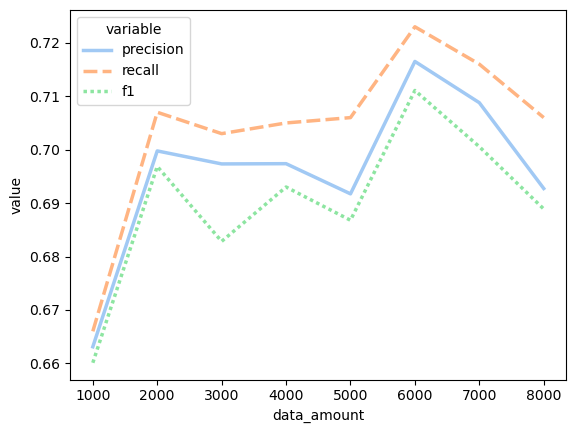

In [9]:
sns.lineplot(data=pd.melt(stats_df, ['data_amount']), x='data_amount', y='value', style="variable", hue='variable', palette="pastel", linewidth=2.5)

In [10]:
best_model

{'ExtraTreesEntr': 2,
 'RandomForestEntr': 2,
 'ExtraTreesGini': 2,
 'XGBoost': 6,
 'WeightedEnsemble_L2': 4,
 'LightGBM': 2,
 'RandomForestGini': 2,
 'LightGBMXT': 3,
 'LightGBMLarge': 1}

([<matplotlib.patches.Wedge at 0x7e8ee3f5e140>,
 [Text(1.062518406696673, 0.28470095790278555, 'ExtraTreesEntr'),
  Text(0.7778174410990706, 0.7778174775113337, 'RandomForestEntr'),
  Text(0.28470090816270893, 1.0625184200244855, 'ExtraTreesGini'),
  Text(-0.7778174957174646, 0.7778174228929383, 'XGBoost'),
  Text(-0.95262790983307, -0.5500000594609754, 'WeightedEnsemble_L2'),
  Text(-0.28470085842263176, -1.0625184333522957, 'LightGBM'),
  Text(0.2847010573829367, -1.062518380041041, 'RandomForestGini'),
  Text(0.8726887474656803, -0.6696374765847432, 'LightGBMXT'),
  Text(1.0905893637545903, -0.14357868806114082, 'LightGBMLarge')],
 [Text(0.5795554945618215, 0.15529143158333755, '8%'),
  Text(0.4242640587813112, 0.4242640786425456, '8%'),
  Text(0.15529140445238668, 0.5795555018315375, '8%'),
  Text(-0.42426408857316245, 0.42426404885069363, '25%'),
  Text(-0.5196152235453109, -0.3000000324332593, '17%'),
  Text(-0.15529137732143547, -0.5795555091012521, '8%'),
  Text(0.1552914858452

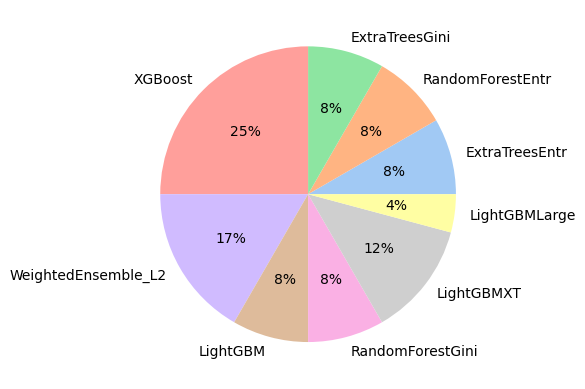

In [11]:
colors = sns.color_palette('pastel')[0:20]
plt.pie(list(best_model.values()), labels=list(best_model), colors = colors, autopct='%.0f%%')

In [12]:
best_features

{'Feature 3': 6,
 'Feature 1': 8,
 'Feature 2': 4,
 'Feature 5': 3,
 'Feature 6': 3}

([<matplotlib.patches.Wedge at 0x7e8ee3f85240>,
 [Text(0.7778174593052024, 0.7778174593052023, 'Feature 3'),
  Text(-0.9526279613277876, 0.5499999702695114, 'Feature 1'),
  Text(-0.5499999256737775, -0.9526279870751434, 'Feature 2'),
  Text(0.42095187075142615, -1.0162674463500614, 'Feature 5'),
  Text(1.0162675251747608, -0.4209516804517678, 'Feature 6')],
 [Text(0.4242640687119285, 0.42426406871192845, '25%'),
  Text(-0.5196152516333387, 0.29999998378336984, '33%'),
  Text(-0.29999995945842406, -0.5196152656773508, '17%'),
  Text(0.2296101113189597, -0.5543276980091243, '12%'),
  Text(0.5543277410044148, -0.229610007519146, '12%')])

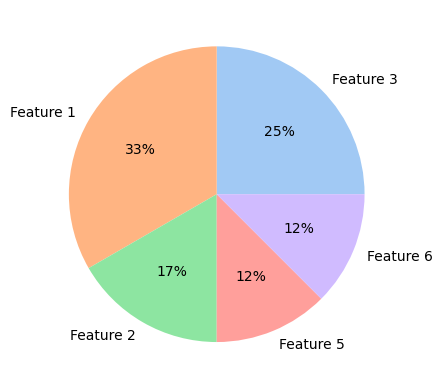

In [13]:
plt.pie(list(best_features.values()), labels=list(best_features), colors = colors, autopct='%.0f%%')